### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [82]:
data = pd.read_csv('data/coupons.csv')

In [83]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [84]:
#To anchor the column names in our minds, let's print their names out 
display(data.columns)

#print the shape of the dataset for added perspective
print(f"The dataset contains {data.shape[0]} rows and {data.shape[1]} columns.")

#Investigate columns names with missing values, and the number of missing values in each column
print("Columns with missing values and their counts:")
display(data.isna().sum()[data.isna().sum() > 0])

print("Percentage of missing values in each column:")
missing_data = data.isna().sum()[data.isna().sum() > 0]
missing_df = pd.DataFrame({
        'count': missing_data,
       'percentage': (missing_data / len(data)) * 100
    })
display(missing_df)

print(
"""
This showed 6 columns with missing data, seems like car is the one with the most missing values,
which can affect the findings later on, as it's missing in 99% of the rows. 
We will have to decide how to handle this column later on, but for now let's just note it down. 
The rest of the columns with missing values have a much smaller percentage of missing data (1.7% or less), 
so we can consider removes the rows with these missing values to without losing too much information.

""" )

# Next, let's store these column names in a list for later use
cols_with_missing = data.columns[data.isna().any()].tolist()
print(f"Columns with missing values: {cols_with_missing}")

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

The dataset contains 12684 rows and 26 columns.
Columns with missing values and their counts:


car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64

Percentage of missing values in each column:


,count,percentage
car,12576,99.148534
Bar,107,0.843582
CoffeeHouse,217,1.710817
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Restaurant20To50,189,1.490066



This showed 6 columns with missing data, seems like car is the one with the most missing values,
which can affect the findings later on, as it's missing in 99% of the rows. 
We will have to decide how to handle this column later on, but for now let's just note it down. 
The rest of the columns with missing values have a much smaller percentage of missing data (1.7% or less), 
so we can consider removes the rows with these missing values to without losing too much information.


Columns with missing values: ['car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


3. Decide what to do about your missing data -- drop, replace, other...

In [85]:

print("""
      
First, let's drop the rows with missing values in the columns that have a small percentage of missing data. 
This will help us to clean the dataset without losing too much information.
      
""")

#Drop rows with missing values in the columns that have a small percentage of missing data, we target 2% as a threshold for this decision

cols_to_drop_na = [col for col in cols_with_missing if (data[col].isna().sum() / len(data)) < 0.02]
data = data.dropna(subset=cols_to_drop_na)
display(data.head())

#Let's check the unique values for each the car column, which has the most missing values, 
#to see if we can find any patterns or insights that can help us decide how to handle the missing values in this column.
print(f"Unique values in the car columns: {data['car'].unique()}")

print(
"""
Since dropping rows is not an option with the car column. Let's focus on the unique values in this column. 
There seems to be two logical assumptions we can make based on the unique values in the car column:
1. The missing values in the car column could represent customers who do not own a car,
2. The missing values could represent customers who own a car but information could not be provided.

For #1, if we compare against the pessenger columnm, we would be able to tell if the customer is likely to own a car or not, 
as it's unlikely that a customer with any type of pessenger would not own a car.
"""
)

print(f"Unique values in the passanger column: {data['passanger'].unique()}")


#Count the number of rows with 'Alone' value in the passanger column
alone_passenger_count = data.loc[(data['passanger'] == 'Alone') & (data['car'].isna())].shape[0]
print(f"Number of rows with 'Alone' value in the passanger column, and missing car information: {alone_passenger_count}")

#Let's check the values in the car column for rows where the passanger column has a value of 'Alone',
#to see if we can find any patterns or insights that can help us decide how to handle the missing values in the car column for these rows.
print(f'Unique values in the car column for rows where the passanger column has a value of "Alone": {data.loc[(data['passanger'] == 'Alone') & (data['car'].notna()), "car"].unique()}')

print("\nMultiple unique values are there, so we can't assume one value for the missing values in the car column for rows where the passanger column has a value of 'Alone'.")

#For simplicity, let's substitute the missing values with values of the passanger column 
#for rows where the car column is nan. Let's then put the results in a new column called car_or_passanger to reflect this change.
data['car_or_passenger'] = data.apply(lambda row: row['passanger'] if pd.isna(row['car']) else row['car'], axis=1)

#Now, let's check how many rows still have missing values in the car_or_passenger column after this data fill
remaining_missing_car = data['car_or_passenger'].isna().sum()
print(f"Number of rows with missing car information after fill: {remaining_missing_car}, percentage: {(remaining_missing_car / len(data)) * 100:.2f}% ")

#Let's visualy inspect our work
display(data[data['car'].isna()][['car', 'passanger', 'car_or_passenger']].head(10))
display(data[data['car'].notna()][['car', 'passanger', 'car_or_passenger']].head(10))



First, let's drop the rows with missing values in the columns that have a small percentage of missing data. 
This will help us to clean the dataset without losing too much information.




,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


Unique values in the car columns: [nan 'Scooter and motorcycle' 'crossover' 'Mazda5' 'do not drive'
 'Car that is too old to install Onstar :D']

Since dropping rows is not an option with the car column. Let's focus on the unique values in this column. 
There seems to be two logical assumptions we can make based on the unique values in the car column:
1. The missing values in the car column could represent customers who do not own a car,
2. The missing values could represent customers who own a car but information could not be provided.

For #1, if we compare against the pessenger columnm, we would be able to tell if the customer is likely to own a car or not, 
as it's unlikely that a customer with any type of pessenger would not own a car.

Unique values in the passanger column: ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
Number of rows with 'Alone' value in the passanger column, and missing car information: 6913
Unique values in the car column for rows where the passanger column has a v

,car,passanger,car_or_passenger
22,NaN,Alone,Alone
23,NaN,Friend(s),Friend(s)
24,NaN,Friend(s),Friend(s)
25,NaN,Friend(s),Friend(s)
26,NaN,Friend(s),Friend(s)
27,NaN,Friend(s),Friend(s)
28,NaN,Friend(s),Friend(s)
29,NaN,Friend(s),Friend(s)
30,NaN,Friend(s),Friend(s)
31,NaN,Friend(s),Friend(s)


,car,passanger,car_or_passenger
1237,Scooter and motorcycle,Alone,Scooter and motorcycle
1238,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1239,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1240,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1241,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1242,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1243,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1244,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1245,Scooter and motorcycle,Friend(s),Scooter and motorcycle
1246,Scooter and motorcycle,Friend(s),Scooter and motorcycle


4. What proportion of the total observations chose to accept the coupon?



In [86]:
print("""
The proportion of the total observations choosing to acceopt a coupon would be the percentage of Y == 1 from the total observations
""")
acceptance_rate = (data['Y'] == 1).sum() / len(data) * 100    


print(f"{acceptance_rate:.2f}% of the total observations chose to accept a coupon.")


The proportion of the total observations choosing to acceopt a coupon would be the percentage of Y == 1 from the total observations

56.93% of the total observations chose to accept a coupon.


5. Use a bar plot to visualize the `coupon` column.

/var/folders/l0/0wtgdvdx09sbm632tdzqtlh40000gn/T/ipykernel_9771/301470612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='coupon', data=data, palette='viridis')


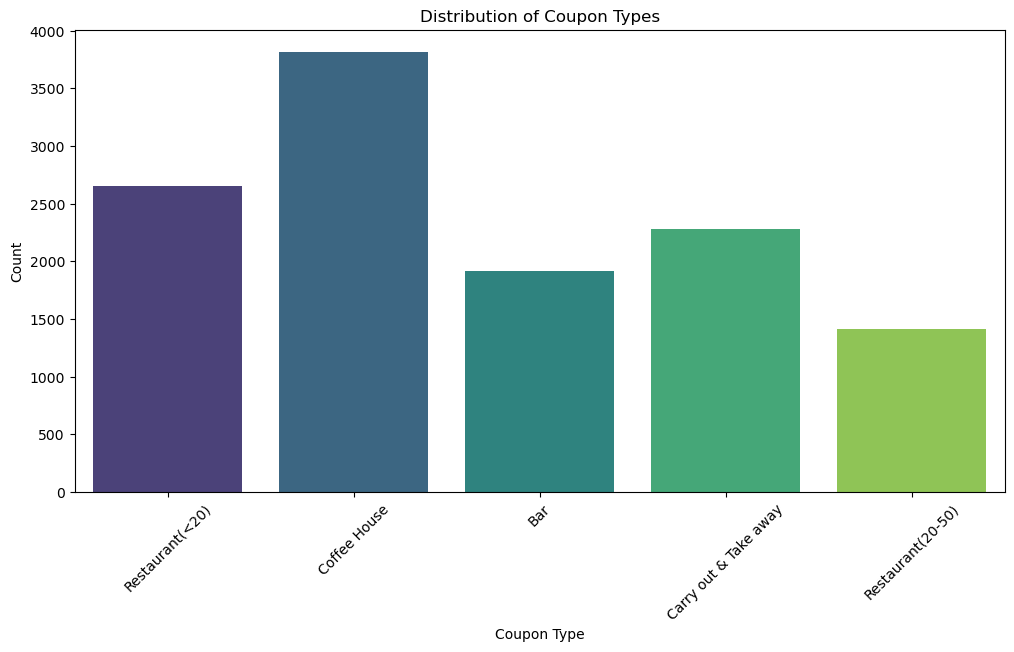

In [87]:
plt.figure(figsize=(12, 6))
sns.countplot(x='coupon', data=data, palette='viridis')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
#let's rotate the x-axis labels for better readability, as some of the coupon types have long names
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

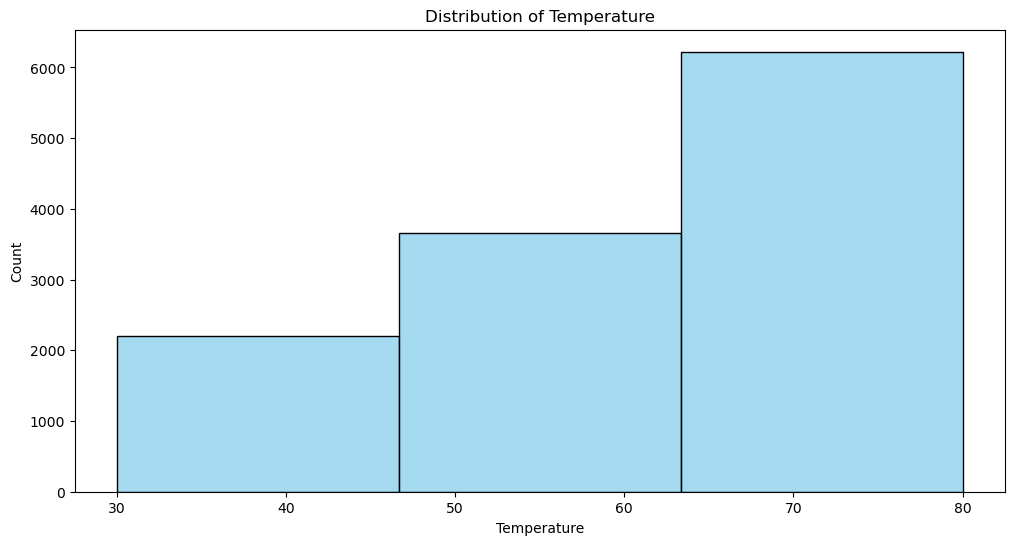

In [88]:
plt.figure(figsize=(12, 6))
#After some experimentation, I found that using 3 bins for the temperature column gives a good balance between granularity and readability in the histogram.
sns.histplot(data['temperature'], bins=3,color='skyblue')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [89]:
bar_data = data.query('coupon == "Bar"')
bar_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,car_or_passenger
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,Friend(s)
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,1,0,1,Alone
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,1,1,0,1,1,Alone
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,0,1,0,Friend(s)
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,1,0,0,Alone


2. What proportion of bar coupons were accepted?


In [90]:
print("""
The proportion of bar coupons accepted would be the percentage of Y == 1 from the total bar coupon observations
""")
bar_acceptance_rate = (bar_data['Y'] == 1).sum() / len(bar_data) * 100    

#An observation: Since the value at 'Y' are either 0 or 1, 
#we can interpret the mean of 'Y' as the percentage of observations that accepted the coupon, 
#so we can also calculate the acceptance rate for bar coupons using the mean of 'Y' for the bar_data subset.

print(f"{bar_acceptance_rate:.2f}% of the total observations chose to accept a coupon.")


The proportion of bar coupons accepted would be the percentage of Y == 1 from the total bar coupon observations

41.19% of the total observations chose to accept a coupon.


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [91]:
#Let's investigate the unique values in the Bar column
print(f'Unique values in the Bar column: {bar_data["Bar"].unique().tolist()}')

print('Values in the Bar column representintg more than 3 visits are "gt8" , and "4~8"')

#Compare acceptance rates between more than 3 visits to bar vs less than 3 visits to bar
gt3_vals = ['gt8', '4~8']
bar_gt3_acceptance_rate = bar_data[bar_data['Bar'].isin(gt3_vals)]['Y'].mean() * 100
bar_le3_oreq_acceptance_rate = bar_data[~bar_data['Bar'].isin(gt3_vals)]['Y'].mean() * 100 #or simply 100 - bar_gt3_acceptance_rate

print(f"Acceptance rate for more than 3 visits: {bar_gt3_acceptance_rate:.2f}%")
print(f"Acceptance rate for 3 or fewer visits: {bar_le3_oreq_acceptance_rate:.2f}%")


Unique values in the Bar column: ['never', 'less1', '1~3', 'gt8', '4~8']
Values in the Bar column representintg more than 3 visits are "gt8" , and "4~8"
Acceptance rate for more than 3 visits: 76.17%
Acceptance rate for 3 or fewer visits: 37.27%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [92]:
#Let's first investigate unique values in the age column
print(f'Unique values in the age column: {bar_data["age"].unique()}')

#There are 8 unique values in the age column. Some of these values are categorical, and we can either convert them to numeric values or analyze them as-is.
# I prefer to use numeric values for better analysis, so let's convert the age column to numeric values by mapping the categorical values to their corresponding numeric ranges.
age_mapping = {
    'below21': 20,
    '21': 21,
    '26': 26,
    '31': 31,
    '36': 36,
    '41': 41,
    '46': 46,
    '50plus': 50
}
bar_data.loc[:, 'age_numeric'] = bar_data['age'].map(age_mapping)

acceptance_rate = bar_data.query('Bar not in ["less1", "never"] and age_numeric > 25')['Y'].mean() * 100
print(f'Acceptance rate for drivers who go to bars more than once a month with age > 25: {acceptance_rate:.2f}% \n')


Unique values in the age column: ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
Acceptance rate for drivers who go to bars more than once a month with age > 25: 68.98% 



/var/folders/l0/0wtgdvdx09sbm632tdzqtlh40000gn/T/ipykernel_9771/2404610263.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_data.loc[:, 'age_numeric'] = bar_data['age'].map(age_mapping)


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [93]:
#Investigate unique values to retrieve exact value for the occupation
print(bar_data['occupation'].unique().tolist())

#Since this is a larger query, let's store it in a variable for better readability & maintainability
query_str = 'Bar not in ["less1", "never"] and passanger != "Kid(s)" and occupation != "Farming Fishing & Forestry"'

acceptance_rate = bar_data.query(query_str)['Y'].mean() * 100
print(f'Acceptance rate for drivers who go to bars more than once a month, with no kids passengers, and not in farming, fishing or forestry: {acceptance_rate:.2f}%')


['Architecture & Engineering', 'Student', 'Education&Training&Library', 'Unemployed', 'Healthcare Support', 'Healthcare Practitioners & Technical', 'Sales & Related', 'Management', 'Arts Design Entertainment Sports & Media', 'Computer & Mathematical', 'Life Physical Social Science', 'Personal Care & Service', 'Office & Administrative Support', 'Construction & Extraction', 'Legal', 'Retired', 'Community & Social Services', 'Installation Maintenance & Repair', 'Transportation & Material Moving', 'Business & Financial', 'Protective Service', 'Food Preparation & Serving Related', 'Production Occupations', 'Building & Grounds Cleaning & Maintenance', 'Farming Fishing & Forestry']
Acceptance rate for drivers who go to bars more than once a month, with no kids passengers, and not in farming, fishing or forestry: 70.94%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [94]:
#Let's create query strings for each group of conditions we want to analyze, 
#and then calculate the acceptance rate for each group using these query strings. 

query1 = 'Bar not in ["less1", "never"] and passanger != "Kid(s)" and maritalStatus != "Widowed"'
query2 = 'Bar not in ["less1", "never"] and age_numeric < 30'
query3 = 'RestaurantLessThan20 in ["4~8", "gt8"] and income in ["$12500 - $24999", "$25000 - $37499", "$37500 - $49999"]'

acceptance_rate1 = bar_data.query(query1)['Y'].mean() * 100
acceptance_rate2 = bar_data.query(query2)['Y'].mean() * 100
acceptance_rate3 = bar_data.query(query3)['Y'].mean() * 100
print("\nAcceptance rates for different groups of conditions:")
print(f'go to bars more than once a month, had passengers that were not a kid, and were not widowed: {acceptance_rate1:.2f}%')
print(f'go to bars more than once a month and are under 30: {acceptance_rate2:.2f}%')
print(f'go to cheap restaurants more than 4 times a month and income is less than 50K: {acceptance_rate3:.2f}%')
print("=======\n")

#Let's try to 'OR' the three conditions together to see the acceptance rate for customers that satisfy at least one of these conditions
query_or = f'({query1}) or ({query2}) or ({query3})'
acceptance_rate_or = bar_data.query(query_or)['Y'].mean() * 100
print(f'Acceptance rate for customers that satisfy at least one of the conditions: {acceptance_rate_or:.2f}%')


Acceptance rates for different groups of conditions:
go to bars more than once a month, had passengers that were not a kid, and were not widowed: 70.94%
go to bars more than once a month and are under 30: 71.95%
go to cheap restaurants more than 4 times a month and income is less than 50K: 46.15%

Acceptance rate for customers that satisfy at least one of the conditions: 61.15%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?


      One very logical hypothesis here is how much the acceptance rate positively correlates with the number of times the customer visits a bar. 
      


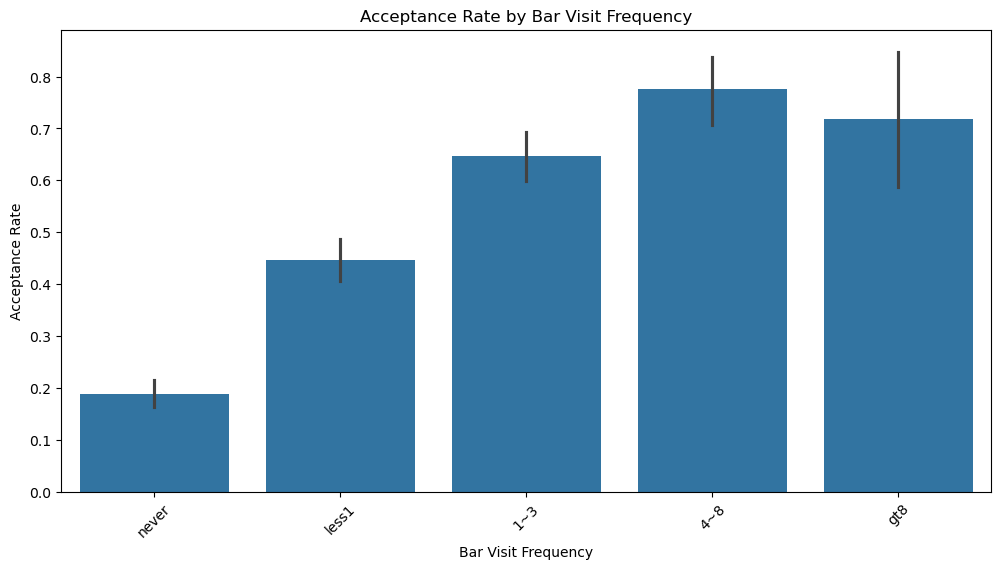


      It's clear the number of visits to the bar is a very reliable indicator of the acceptance rate. 
      The merital status seems to have an effect as well. 
      


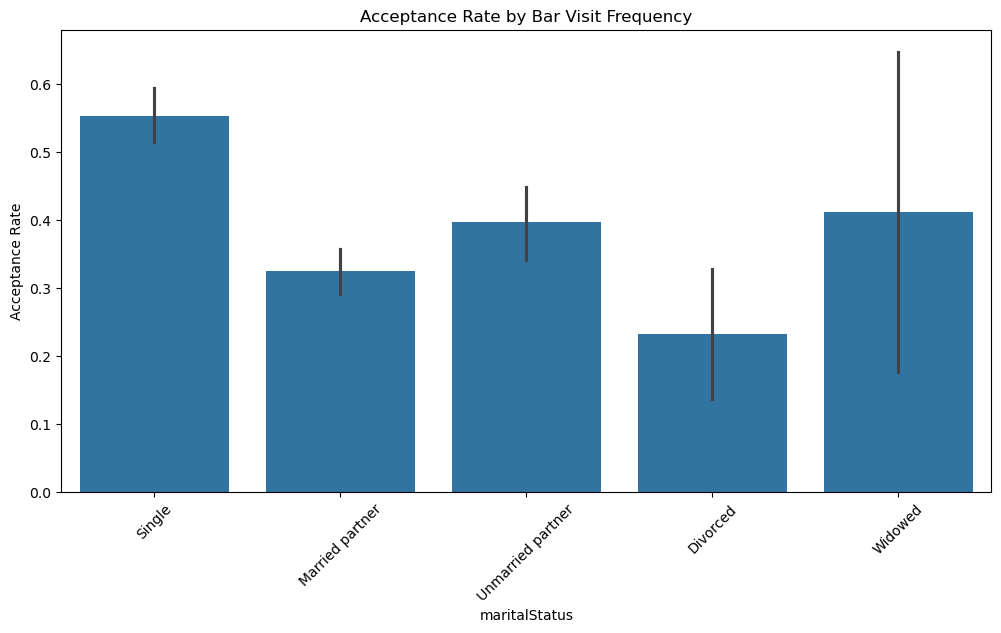

Age also seems to have an effect


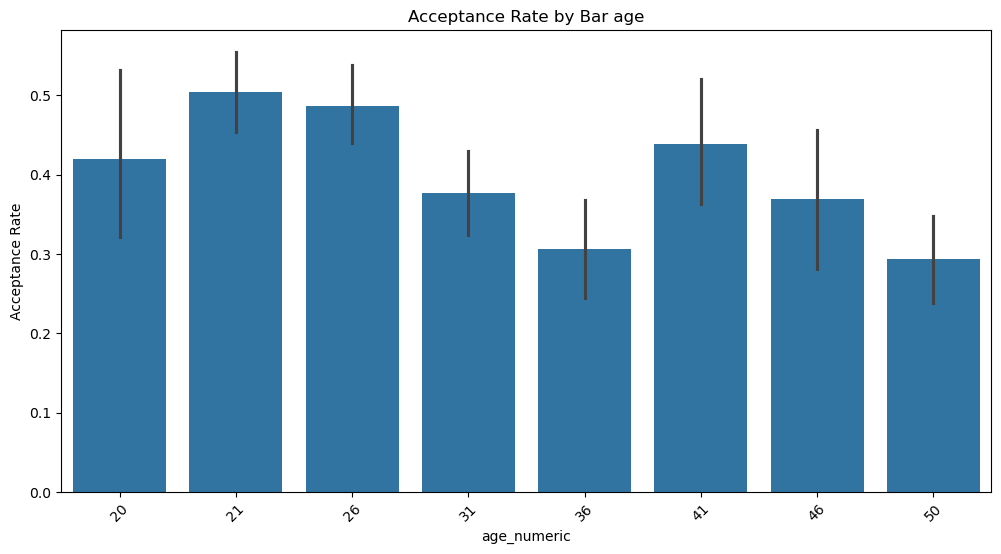


      Combining number of visits to bar with income level gives us even more insights,
      It seems certain income ranges combined with certain visit frequencies can achieve almost 100% acceptance rate



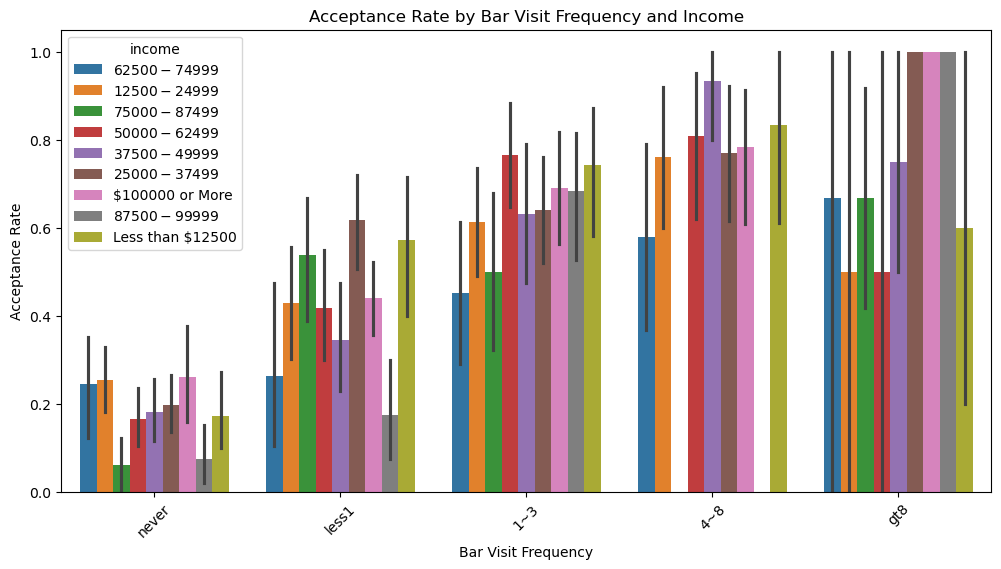

In [95]:
print("""
      One very logical hypothesis here is how much the acceptance rate positively correlates with the number of times the customer visits a bar. 
      """)

#Plot correlation between the number of times the customer visits a bar and the acceptance rate, with merital status as a hue, we can use a bar plot to visualize this relationship.
#will crearte a function to reuse

def plot_bar_acceptance_rate(data, x_col,title, x_l = None, hue_col = None, order=None):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=x_col, 
        y='Y', 
        data=data, 
        hue=hue_col, 
        estimator=np.mean, 
        order=order)
    plt.title(title)
    if x_l:
        plt.xlabel(x_l)
    else:
        plt.xlabel(x_col)
    plt.ylabel('Acceptance Rate')
    plt.xticks(rotation=45)
    plt.show()

order = ['never', 'less1', '1~3', '4~8', 'gt8']


plot_bar_acceptance_rate(
    data=bar_data, 
    x_col='Bar', 
    title='Acceptance Rate by Bar Visit Frequency', 
    x_l='Bar Visit Frequency',
    order=order)

print("""
      It's clear the number of visits to the bar is a very reliable indicator of the acceptance rate. 
      The merital status seems to have an effect as well. 
      """)

plot_bar_acceptance_rate(
    data=bar_data, 
    x_col='maritalStatus', 
    title='Acceptance Rate by Bar Visit Frequency')

print("Age also seems to have an effect")
plot_bar_acceptance_rate(
    data=bar_data, 
    x_col='age_numeric', 
    title='Acceptance Rate by Bar age')

print("""
      Combining number of visits to bar with income level gives us even more insights,
      It seems certain income ranges combined with certain visit frequencies can achieve almost 100% acceptance rate
""")

plot_bar_acceptance_rate(
    data=bar_data, 
    x_col='Bar', 
    title='Acceptance Rate by Bar Visit Frequency and Income', 
    x_l='Bar Visit Frequency',
    hue_col='income', order=order)



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [96]:
    
"""
Let's investigate the impact of the rest of the columns on Y by using groupby per column, 
then relying on the mean of 'Y' to reflect the acceptance rate. 
"""
#This is a function that takes a column name and a threshold value, 
#then return a column name if there are values in the column that have an acceptance rate above the threshold, and return None if there are no values that meet this condition.
def check_impact(data, column_name, threshold=0.7):
    impact = data.groupby(column_name)['Y'].mean().sort_values(ascending=False)
    impact = impact[impact >= threshold]
    if impact.empty:
        return None
    return column_name

#Extract column names that are not Y
non_Y_cols = [col for col in data.columns if col != 'Y']
#Now, let's loop through these columns and check their impact on the acceptance rate using the function we just created.
#Results will be stored in a column name list
coupon_impactful_cols = []
for col in non_Y_cols:
    if check_impact(data, col) is not None:
        coupon_impactful_cols.append(col)
        
print(f"Columns with noticeable impact on acceptance rate: {coupon_impactful_cols}")


Columns with noticeable impact on acceptance rate: ['coupon', 'education', 'occupation', 'car', 'car_or_passenger']


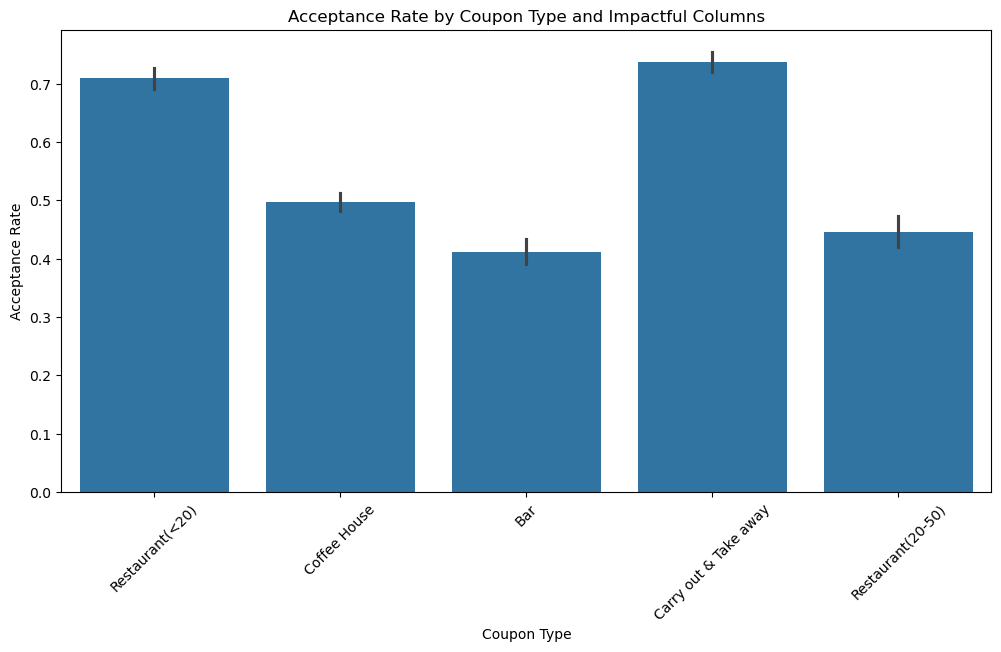


The plot shows that the coupon types with the highest acceptance rates are cheap restaurant (Restaurant(<20)), and carry out coupons.
This suggests that customers are more likely to accept coupons for cheaper dining options and takeout, which could be due to the convenience and cost savings associated with these types of coupons.
This insight can be valuable for businesses when designing their marketing strategies and targeting specific customer segments with the most appealing coupons.



In [97]:
#Seems like the coupon type itself impacts acceptance rate, which is expected, as some coupons are more attractive than others.
#Let's study the coupon types with the most acceptance rate
#plot the acceptance rate for each coupon type, we can use a bar plot to visualize this relationship.
plot_bar_acceptance_rate(
    data=data, 
    x_col='coupon', 
    title='Acceptance Rate by Coupon Type and Impactful Columns', 
    x_l='Coupon Type')

print("""
The plot shows that the coupon types with the highest acceptance rates are cheap restaurant (Restaurant(<20)), and carry out coupons.
This suggests that customers are more likely to accept coupons for cheaper dining options and takeout, which could be due to the convenience and cost savings associated with these types of coupons.
This insight can be valuable for businesses when designing their marketing strategies and targeting specific customer segments with the most appealing coupons.
""")


In [105]:
#Let's investigate the impact of the other columns on each coupon type. 
#We will do this by grouping the data by coupon type, then applying the same function we created earlier to check the impact of each column on the acceptance rate for each coupon type.
#For additional filtering, will set the threshold to 0.8 (80% acceptance rate)

coupon_types = data['coupon'].unique()
print(f"Unique coupon types: {coupon_types}")

for coupon_type in coupon_types:
    data_subset = data[data['coupon'] == coupon_type]
    coupon_impactful_cols = []
    for col in non_Y_cols:
        if check_impact(data_subset, col, 0.8) is not None:
            coupon_impactful_cols.append(col)   
    print(f"Columns with noticeable impact on acceptance rate for {coupon_type}: {coupon_impactful_cols}")

Unique coupon types: ['Restaurant(<20)' 'Coffee House' 'Bar' 'Carry out & Take away'
 'Restaurant(20-50)']
Columns with noticeable impact on acceptance rate for Restaurant(<20): ['passanger', 'time', 'expiration', 'occupation', 'car', 'car_or_passenger']
Columns with noticeable impact on acceptance rate for Coffee House: ['car', 'car_or_passenger']
Columns with noticeable impact on acceptance rate for Bar: ['car', 'car_or_passenger']
Columns with noticeable impact on acceptance rate for Carry out & Take away: ['time', 'maritalStatus', 'education', 'occupation', 'car', 'RestaurantLessThan20', 'car_or_passenger']
Columns with noticeable impact on acceptance rate for Restaurant(20-50): ['car', 'car_or_passenger']


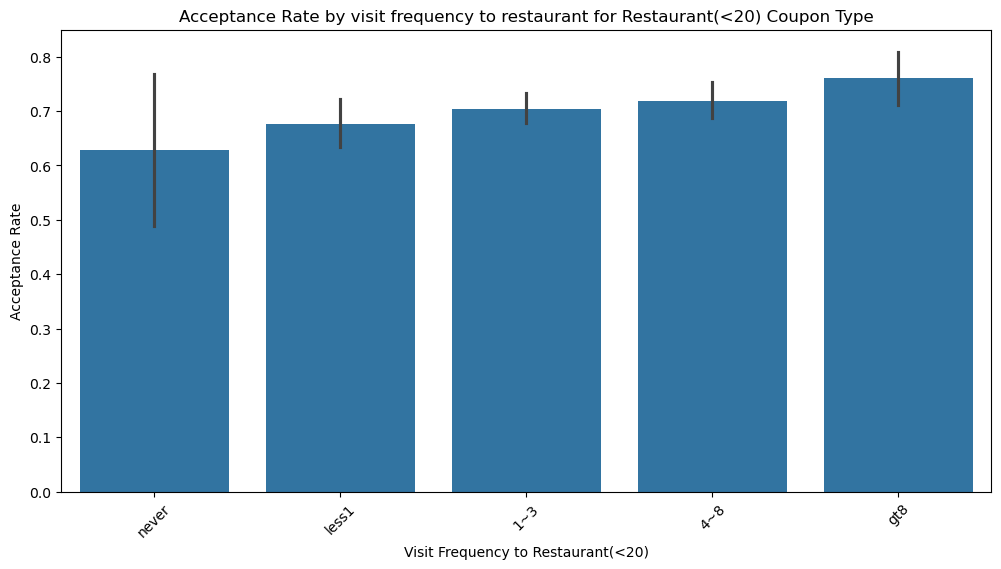


      For the Restaurant(<20) coupon type, it shows the more visit frequency to cheap restaurants, the higher the acceptance rate, which is a logical pattern, as customers who frequently visit cheap restaurants are more likely to be interested in coupons for cheap restaurants.


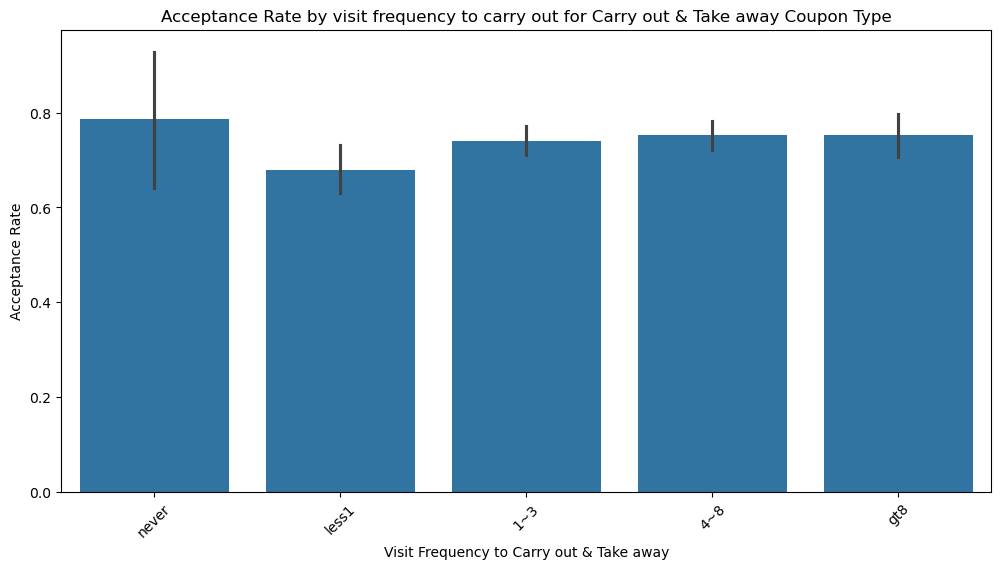


      For the Carry out & Take away coupon type, there is no clear pattern between the visit frequency to carry out and the acceptance rate, as the acceptance rates for different visit frequencies are relatively similar, and there is no noticeable increase or decrease in acceptance rate with increasing visit frequency. 
      This suggests that visit frequency to carry out may not be a strong predictor of acceptance rate for this coupon type, and other factors may be more influential in determining whether customers choose to accept these coupons.
      


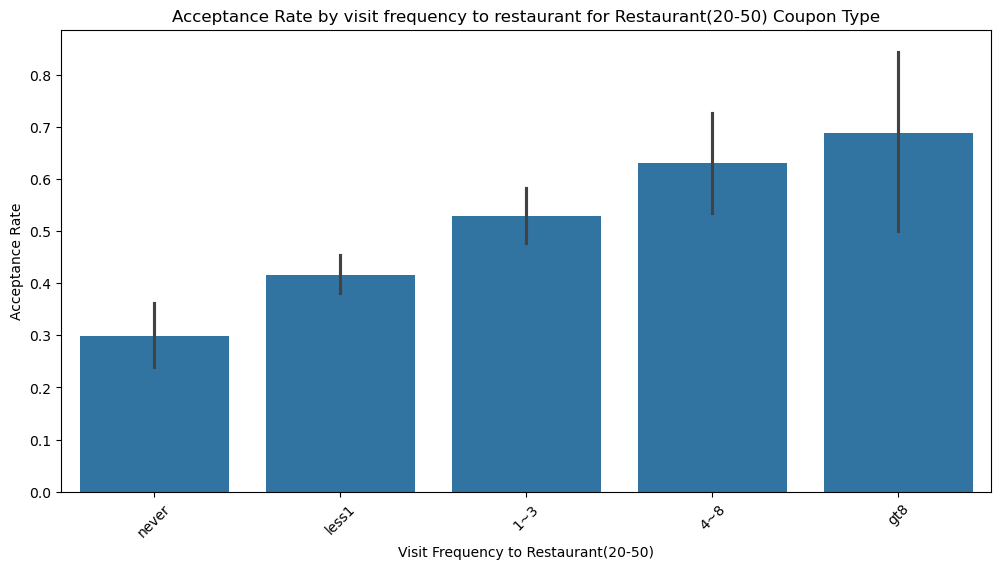


    The visiting habits seem to be a strong indicator of acceptance rate for more expensive restaurants as well. 



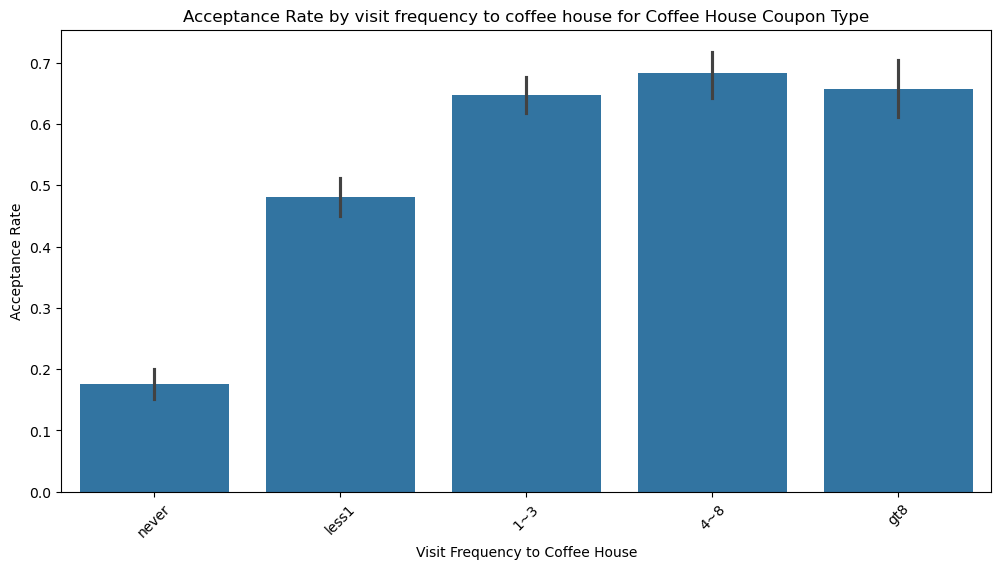

In [ ]:
#Let's investigate the impact of the other columns on Restaurant(<20) coupon type, and Carryout coupon types further
res_ls20 = data[data['coupon'] == 'Restaurant(<20)']
carryout = data[data['coupon'] == 'Carry out & Take away']

#It's interesting that the visit frequency did not show with 80% threshold, 
#Let's plot the acceptance rate for each visit frequency for these two coupon types to see if there are any noticeable patterns, even if they don't meet the 80% threshold.

plot_bar_acceptance_rate(
    data=res_ls20, 
    x_col='RestaurantLessThan20', 
    title='Acceptance Rate by visit frequency to restaurant for Restaurant(<20) Coupon Type', 
    x_l='Visit Frequency to Restaurant(<20)', order=['never', 'less1', '1~3', '4~8', 'gt8'])
    
print("""
      For the Restaurant(<20) coupon type, it shows the more visit frequency to cheap restaurants, the higher the acceptance rate, which is a logical pattern, as customers who frequently visit cheap restaurants are more likely to be interested in coupons for cheap restaurants.""")

plot_bar_acceptance_rate(
    data=carryout, 
    x_col='CarryAway', 
    title='Acceptance Rate by visit frequency to carry out for Carry out & Take away Coupon Type', 
    x_l='Visit Frequency to Carry out & Take away', order=['never', 'less1', '1~3', '4~8', 'gt8'])

print("""
      For the Carry out & Take away coupon type, there is no clear pattern between the visit frequency to carry out and the acceptance rate, as the acceptance rates for different visit frequencies are relatively similar, and there is no noticeable increase or decrease in acceptance rate with increasing visit frequency. 
      This suggests that visit frequency to carry out may not be a strong predictor of acceptance rate for this coupon type, and other factors may be more influential in determining whether customers choose to accept these coupons.
      """)

#What about more expensive restaurant coupons? Do they show a similar pattern to the cheap restaurant coupons?
res_gt20 = data[data['coupon'] == 'Restaurant(20-50)']
plot_bar_acceptance_rate(
    data=res_gt20, 
    x_col='Restaurant20To50', 
    title='Acceptance Rate by visit frequency to restaurant for Restaurant(20-50) Coupon Type', 
    x_l='Visit Frequency to Restaurant(20-50)', order=['never', 'less1', '1~3', '4~8', 'gt8'])

print("""
    The visiting habits seem to be a strong indicator of acceptance rate for more expensive restaurants as well. 
""")

#Let's repeat with coffee shop coupons
coffee = data[data['coupon'] == 'Coffee House']
plot_bar_acceptance_rate(
    data=coffee, 
    x_col='CoffeeHouse', 
    title='Acceptance Rate by visit frequency to coffee house for Coffee House Coupon Type', 
    x_l='Visit Frequency to Coffee House', order=['never', 'less1', '1~3', '4~8', 'gt8'])   

print("""
    For the Coffee House coupon type, it is safe to assume that more visits to coffee houses is associated with higher acceptance rates, as proved by the data
""")

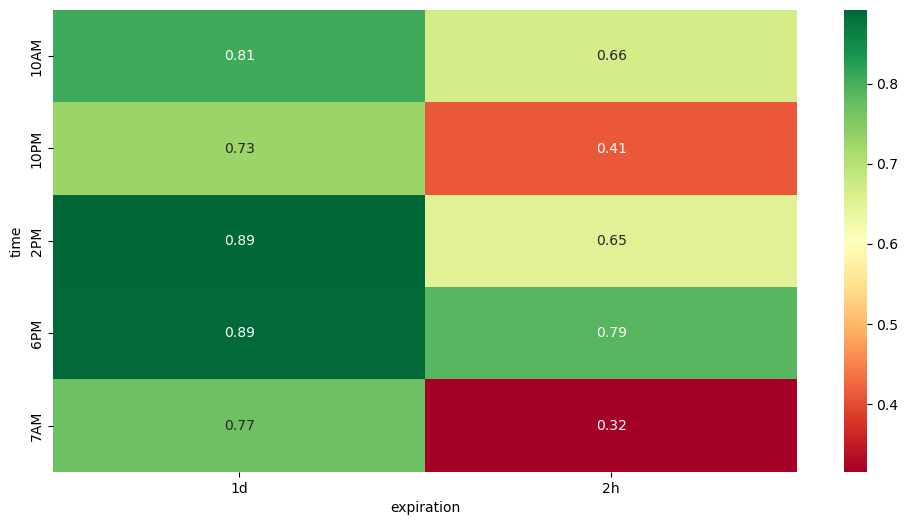


    The heatmap shows that for the Restaurant(<20) coupon type, 
      the acceptance rate is highest when the coupon has a long expiration duration. and a current time between the range of 2pm-6pm.
      On the other hand, the acceptance rate is lowest when the coupon has a short expiration duration and a current time in the early morning 7am or late evening 10pm).



In [100]:
#Let's try a heat map to visualize the impact on time, expiration on acceptance rate for the restaurant(<20) coupon type, 
#as these are two of the columns that showed a noticeable impact on acceptance rate for this coupon type.
plt.figure(figsize=(12, 6))
pivot = res_ls20.pivot_table(index='time', columns='expiration', values='Y', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn')
plt.show()

print("""
    The heatmap shows that for the Restaurant(<20) coupon type, 
      the acceptance rate is highest when the coupon has a long expiration duration. and a current time between the range of 2pm-6pm.
      On the other hand, the acceptance rate is lowest when the coupon has a short expiration duration and a current time in the early morning 7am or late evening 10pm).
""")

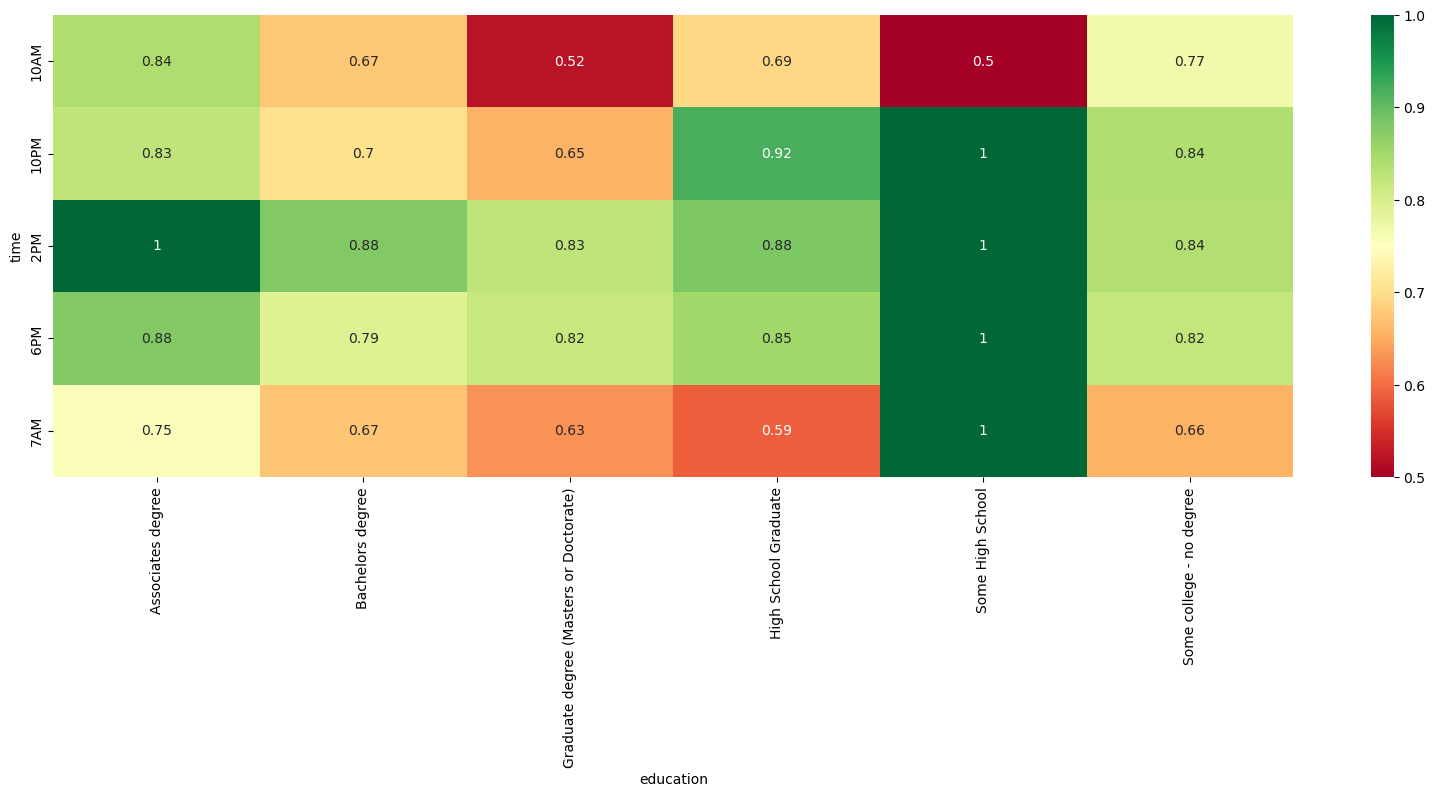


    The heatmap shows that for the Carry out coupon type,
      the acceptance rate is highest when the customer has some high school education, with extremely strong acceptance rates (100%) across all but one time periods. The exception is 10 AM, where the acceptance rate is only 50%.
      This suggests that these categories of customers are reliable drivers of acceptance rate for the carry out coupon type, and that targeting these customers with carry out coupons in the right time spans could be a very effective marketing strategy.
      On the other hand, graduate degree holders only show high acceptance rate at 2pm-6pm current time. 
    


In [101]:
#Let's try a heat map to visualize the impact on time, occupation on acceptance rate for the carry out coupon type, 
#as these are two of the columns that showed a noticeable impact on acceptance rate for this coupon type.
plt.figure(figsize=(20, 6))
pivot = carryout.pivot_table(index='time', columns='education', values='Y', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn')
plt.show()

print("""
    The heatmap shows that for the Carry out coupon type,
      the acceptance rate is highest when the customer has some high school education, with extremely strong acceptance rates (100%) across all but one time periods. The exception is 10 AM, where the acceptance rate is only 50%.
      This suggests that these categories of customers are reliable drivers of acceptance rate for the carry out coupon type, and that targeting these customers with carry out coupons in the right time spans could be a very effective marketing strategy.
      On the other hand, graduate degree holders only show high acceptance rate at 2pm-6pm current time. 
    """)

### Final Summary and Strategic Recommendations

#### 1. Summary of Key Findings
Through our analysis of over 12,000 observations, we identified three primary factors driving coupon acceptance:

*   **Establishment Frequency (Habit):** Habitual visitors are the very reliable acceptors. For example, frequent bar-goers (3+ times/month) accepted coupons at a **76.2%** rate, nearly double the rate of infrequent visitors (**37.3%**).
*   **Situational Context (Social/Demographics):** Drivers with **Friends or Partners** in the car were much more likely to accept leisure-based coupons (Bars, Coffee Houses) than those with children or traveling alone. Younger drivers (< 30) were also prime candidates for Bar-related detours.
*   **Timing and Expiration Window:** The afternoon window (**2 PM - 6 PM**) is universally strong, but for inexpensive restaurants, acceptance peaks (**80%+**) specifically when the coupon has a **1-day expiration** period. Short-duration (2-hour) coupons suffer significantly during off-peak morning and evening hours.

#### 2. Actionable Items
Based on the analysis, the following actions are recommended for immediate marketing deployment:

*   **Segment Carry-Out by Education:** Prioritize the "Some High School" and "Student" segments for Carry-Out coupons, as they exhibited near **100% acceptance** across most time periods except for 10AM.
*   **Optimize Bar Coupon Trigger:** Trigger Bar coupons specifically when a driver is detected to be under 30 and/or has friends in the vehicle.
*   **Adjust Expiration Defaults:** Transition restaurant coupons sent during the 2 PM - 6 PM window to a **1-day expiration** to capture drivers who may not want to take an immediate detour but will do so later in the day.

#### 3. Recommendations
*   **Personalized Profiles:** Develop a profile for each user based on their historical visit frequency, and how it changes with targeted coupons.
*   **Car data:** There was a significant amount of data missing about the car types, so the analysis had to make assumptions about the missing values. This should be investigated and addressed in the future, so that when the analysis is executed again, it can account for this data. 